In [80]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [81]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [82]:

@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost
     

In [83]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])
     


In [84]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
         return state == self.goal
    

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2: Return a list of legal action names.
        
        legal_actions = []
        row, col = state
        for action, (r, c) in MOVES.items():
            neighbour = (row + r, col + c)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3: Return the next state after applying action to state.
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4: In this lab, each valid move has a cost of 1.
        return 1.
    

class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5: Implement the AIMA-style EXPAND(problem, node).
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)
            
    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [85]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [86]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1: Return the cost of moving from state to next_state.
        # 1. Unpack next_state into row and col.
        row, col = next_state
        # 2. Return self.terrain_costs[row][col].
        return self.terrain_costs[row][col]
        

In [87]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [88]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2: Return the Manhattan distance between state and goal.
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    r1, c1 = state
    r2, c2 = goal
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    return abs(r1 - r2) + abs(c1 - c2)

def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:Return the straight-line distance between state and goal.
    r1, c1 = state
    r2, c2 = goal
    return math.sqrt((r1 - r2)**2 + (c1 - c2)**2)



def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [89]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")
     

Heuristic self-check passed.


In [90]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0
     

In [91]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4: Implement the BEST-FIRST-SEARCH pseudocode above.
    
        # 1. Create the initial node from problem.initial_state().
        node = Node(state=problem.initial_state())
        
        # 2. Create a PriorityQueue frontier and push the initial node
        #with priority self.evaluation(node, problem).
        frontier = PriorityQueue()
        frontier.push(self.evaluation(node, problem), node)

        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        # the initial state.
        reached = {problem.initial_state(): node}

        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
       
        nodes_expanded = 0
        max_frontier_size = 1

        # 5. While the frontier is not empty:

        while frontier:

        #a. pop the node with the lowest f-value.
           node = frontier.pop()
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
           if problem.is_goal(node.state):
               return SearchResult(
                   algorithm=self.algorithm_name,
                   status="success",
                   solution=node,
                   nodes_expanded=nodes_expanded,
                   max_frontier_size=max_frontier_size,
                   reached_count=len(reached),
            )
       
        #c. increment nodes_expanded.
           nodes_expanded += 1
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
           for child in self.expand(problem, node):
            s = child.state
            if s not in reached or child.path_cost < reached[s].path_cost:
                reached[s] = child
                frontier.push(self.evaluation(child, problem), child)

        #e. update max_frontier_size with len(frontier).
           max_frontier_size = max(max_frontier_size, len(frontier))

        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.
        return SearchResult(
        algorithm=self.algorithm_name,
        status="failure",
        solution=None,
        nodes_expanded=nodes_expanded,
        max_frontier_size=max_frontier_size,
        reached_count=len(reached),
    )
       

In [92]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        return self.h(node, problem)

In [93]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
        return node.path_cost + self.h(node, problem)

In [94]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost
     

In [95]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost + self.weight * self.h(node, problem)
    

In [96]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")
     

Algorithm self-check passed.


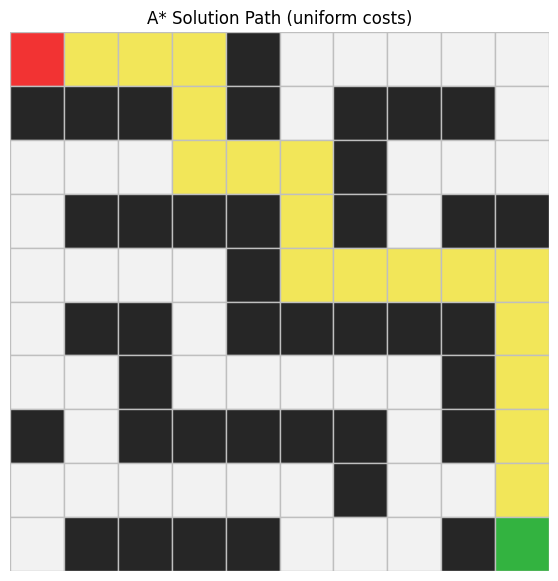

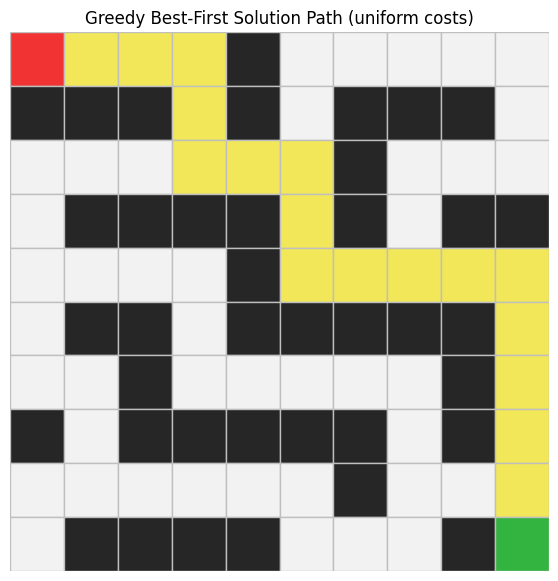

In [97]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)
     

# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)
     

In [98]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


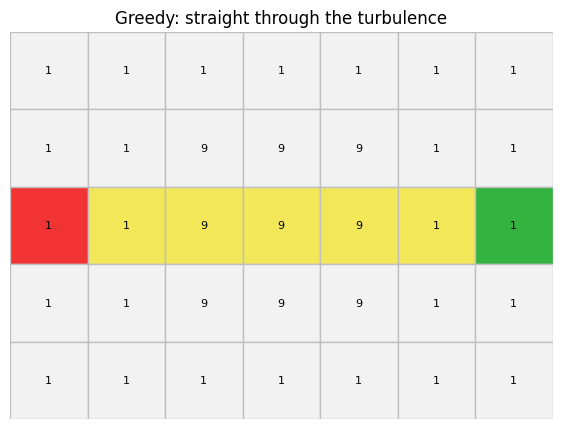

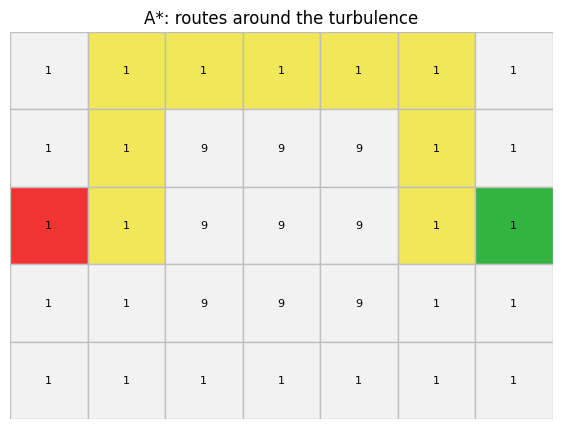

In [99]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [100]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
     def h(state, goal):
        return factor * manhattan_distance(state, goal)
     return h
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)
     

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18.0,18,5,23
1,A* inflated x3 (uniform map),success,18,18.0,18,5,23
2,A* admissible (mild turbulence),success,10,10.0,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12.0,6,13,19


## Record your observations in a markdown cell here:

## On which map(s) did the inflated heuristic return a suboptimal path? By how much?
A* inflated x3 returned a suboptimal path only on the mild turbulence map where it got a cost of 12
compared to A* admissible which got the optimal cost of 10.
On the uniform map both A* admissible and A* inflated x3 got the same cost of 18 because
every cell costs 1 so there is no expensive terrain to avoid and both heuristics guided
the drone along the same path regardless of how much the heuristic overestimated.

## How many fewer nodes did it expand?
On the mild turbulence map A* inflated x3 expanded only 6 nodes compared to A* admissible 
which expanded 29 nodes, a difference of 23 nodes, because the inflated heuristic made the
search more aggressive and decisive pushing it straight toward the goal without exploring the
detour paths that  A* admissible considered.
On the uniform map both expanded the same 18 nodes because with uniform costs of 1 
everywhere the inflated heuristic and the real heuristic rank nodes in the same order so the search follows the exact same path.

## In one or two sentences: when would you, as the drone's engineer, deliberately accept an inadmissible heuristic?
I would accept an inadmissible heuristic when the drone needs to find a path fast and 
a slightly suboptimal path is acceptable because on the mild turbulence map A* inflated x3 expanded only 6 nodes
instead of A* admissible's 29 nodes which is a huge reduction in computation for just a cost difference of 2.

In [101]:
#Map 1: Cheap Long Way vs Expensive Short Way
custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_1 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 3, 3, 3, 3, 3, 3, 3, 3, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 3, 3, 3, 3, 3, 3, 3, 3, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]

custom_start_1 = (2, 0)
custom_goal_1  = (2, 9)

custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1,
    terrain_costs=custom_costs_1
)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]

show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,13,13,42,12,50
1,A*,success,13,13,27,17,43
2,Weighted A* (W=2),success,13,13,18,16,31
3,Greedy,success,9,73,9,19,28


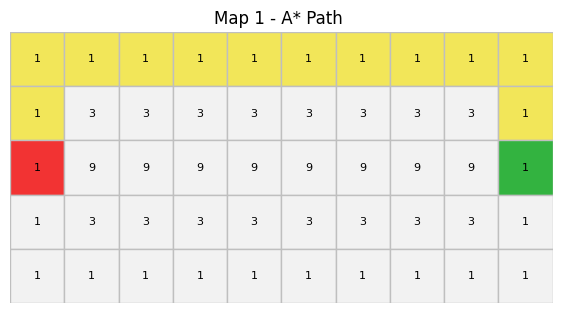

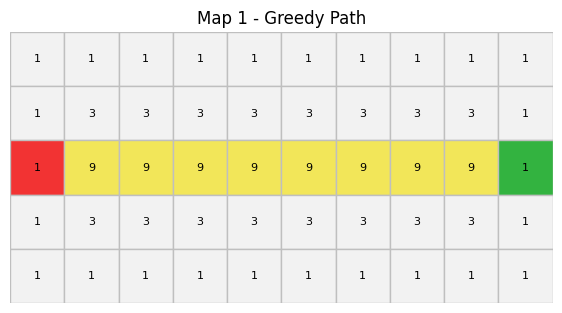

In [102]:
plot_path(
    custom_grid_1, custom_start_1, custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="Map 1 - A* Path ",
)

plot_path(
    custom_grid_1, custom_start_1, custom_goal_1,
    path=custom_results_1[3].path,
    terrain_costs=custom_costs_1,
    title="Map 1 - Greedy Path",
)

In [103]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_2 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1],
    [1, 1, 3, 5, 5, 5, 5, 5, 5, 5, 5, 3, 1, 1, 1],
    [1, 1, 3, 5, 7, 7, 7, 7, 7, 7, 5, 3, 1, 1, 1],
    [1, 1, 3, 5, 7, 9, 9, 9, 9, 7, 5, 3, 1, 1, 1],
    [1, 1, 3, 5, 7, 9, 9, 9, 9, 7, 5, 3, 1, 1, 1],
    [1, 1, 3, 5, 7, 7, 7, 7, 7, 7, 5, 3, 1, 1, 1],
    [1, 1, 3, 5, 5, 5, 5, 5, 5, 5, 5, 3, 1, 1, 1],
    [1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1],
    [1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]

custom_start_2 = (7, 0)
custom_goal_2  = (7, 14)

# Example after completing:
custom_problem_2 = WeightedGridProblem(
custom_grid_2, custom_start_2, custom_goal_2, 
terrain_costs=custom_costs_2)

custom_results_2 = [
 ucs.search(custom_problem_2),
 astar.search(custom_problem_2),
 wastar2.search(custom_problem_2),
 greedy.search(custom_problem_2),]

show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,24,24,133,18,145
1,A*,success,24,24,34,29,62
2,Weighted A* (W=2),success,24,24,29,32,61
3,Greedy,success,34,106,66,36,97


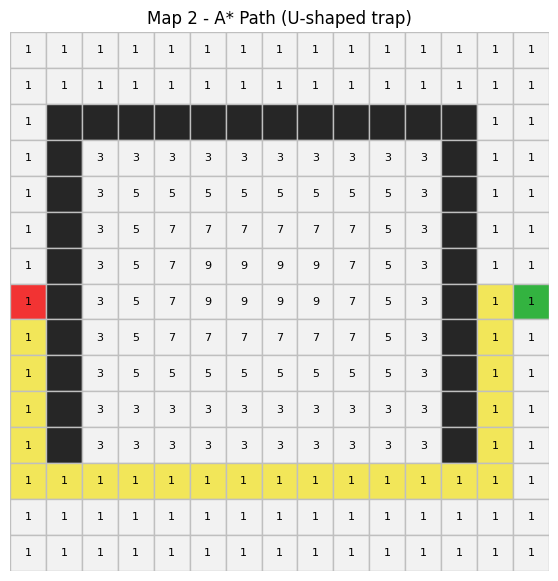

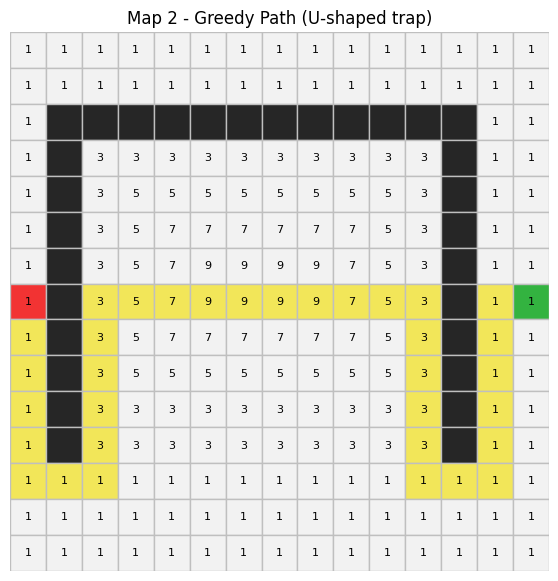

In [104]:
plot_path(
    custom_grid_2, custom_start_2, custom_goal_2,
    path=custom_results_2[1].path,
    terrain_costs=custom_costs_2,
    title="Map 2 - A* Path (U-shaped trap)",
)

plot_path(
    custom_grid_2, custom_start_2, custom_goal_2,
    path=custom_results_2[3].path,
    terrain_costs=custom_costs_2,
    title="Map 2 - Greedy Path (U-shaped trap)",
)

In [105]:
custom_grid_3 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_3 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1],
    [1, 1, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 1, 1],
    [1, 1, 3, 5, 7, 7, 7, 7, 7, 7, 7, 5, 3, 1, 1],
    [1, 1, 3, 5, 7, 9, 9, 9, 9, 9, 7, 5, 3, 1, 1],
    [1, 1, 3, 5, 7, 9, 9, 9, 9, 9, 7, 5, 3, 1, 1],
    [1, 1, 3, 5, 7, 9, 9, 9, 9, 9, 7, 5, 3, 1, 1],
    [1, 1, 3, 5, 7, 9, 9, 9, 9, 9, 7, 5, 3, 1, 1],
    [1, 1, 3, 5, 7, 9, 9, 9, 9, 9, 7, 5, 3, 1, 1],
    [1, 1, 3, 5, 7, 7, 7, 7, 7, 7, 7, 5, 3, 1, 1],
    [1, 1, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 1, 1],
    [1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]

custom_start_3 = (0, 7)
custom_goal_3  = (14, 7)

custom_problem_3 = WeightedGridProblem(
    custom_grid_3, custom_start_3, custom_goal_3,
    terrain_costs=custom_costs_3
)

custom_results_3 = [
    ucs.search(custom_problem_3),
    astar.search(custom_problem_3),
    wastar2.search(custom_problem_3),
    greedy.search(custom_problem_3),
]

show_results(custom_results_3)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,26,26,183,31,204
1,A*,success,26,26,100,76,161
2,Weighted A* (W=2),success,26,26,77,51,105
3,Greedy,success,14,78,14,29,43


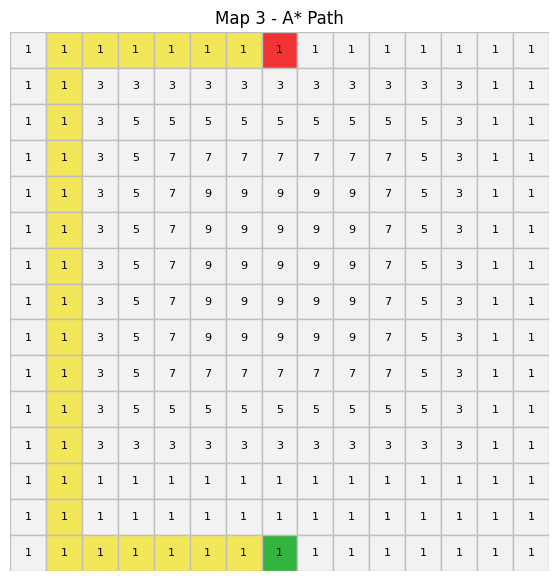

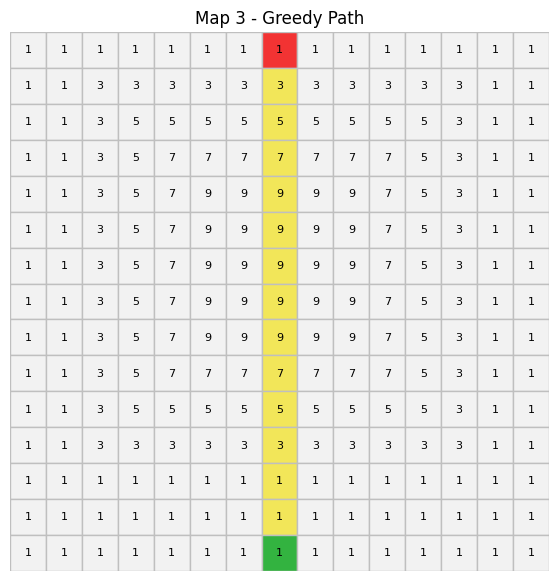

In [106]:
plot_path(
    custom_grid_3, custom_start_3, custom_goal_3,
    path=custom_results_3[1].path,
    terrain_costs=custom_costs_3,
    title="Map 3 - A* Path",
)

plot_path(
    custom_grid_3, custom_start_3, custom_goal_3,
    path=custom_results_3[3].path,
    terrain_costs=custom_costs_3,
    title="Map 3 - Greedy Path",
)

# write a short interpretation (2–4 sentences): which algorithm "won", and on which metric?

For Custom Map 1, Greedy won on nodes expanded (9 nodes) but produced the greatest cost (73) as it looks at the closest path to the goal so it used the cost 9 paths. A* and UCS won on solution quality with the optimal cost of 13 by routing along the cheap top edge. Weighted A* was the overall winner combining both metrics, expanding only 18 nodes while still finding the optimal cost of 13.

For Map 2, A* won the best balance in terms of optimality and efficiency. It has an optimal cost of 24 and expanded only 34 nodes compared to UCS which expanded 133 nodes to find the same cost. Greedy performed worst on both metrics, expanding 66 nodes and returning a cost of 106. Weighted A* won on efficiency with just 29 nodes expanded while still having an optimal cost of 24, making it the most efficient algorithm.

For Map 3, A* and UCS both found the optimal cost of 26 but A* expanded only 100 nodes compared to UCS's 183, showing how much the heuristic saves on a bigger map. Greedy went straight through the expensive center in just 14 steps but paid a cost of 78, about 3x worse than optimal. Weighted A* won here too, matching the optimal cost of 26 while expanding only 77 nodes, fewer than both UCS and A*.

Overall Weighted A* won on all three maps because the weight of 2 pushed it faster toward the goal, so it expanded fewer nodes than A* and UCS but still found the same optimal cost every time.

## Reflection Questions

## 16.1 : Heuristic Functions

## 1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?
it estimates how far the drone still has to travel from its current cell to the goal cell, ignoring obstacles and terrain. its knowledge comes from the drone's GPS, which gives it the current coordinates and the goal coordinates, so it can calculate Manhattan or Euclidean distance between them without knowing anything about what's actually in the way.


## 2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?
it removes two restrictions. first, obstacles, the relaxed version assumes the drone can fly straight through forests, water bodies, and restricted zones as if they were not there. second, terrain costs, every move in the relaxed problem costs 1 regardless of what terrain itis actually entering, so Manhattan distance just counts the minimum number of moves needed in an empty grid.


## 3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?
Manhattan distance dominates Euclidean since it is always greater than or equal to Euclidean distance. domination means Manhattan gives a tighter, more informative estimate, so A* using Manhattan should expand fewer nodes than A* using Euclidean since it has more accurate guidance toward the goal.

## 4. Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?
Manhattan distance assumes every move costs at least 1, since it's just counting steps. if a terrain cost was 0.5, the true cost of reaching the goal could end up being less than what Manhattan distance estimates, meaning it would overestimate and become inadmissible, which is exactly what we saw break optimality in the inflated heuristic experiment.


## 16.2 Greedy Best-First Search


## 1 Which quantity does Greedy ignore, and how did the turbulence map punish it for that?
Greedy ignores g(n), the cost already paid to get to the current node. on the turbulence map, it went straight across in only 6 steps but ended up with a cost of 30 compared to A*'s optimal cost of 10, three times worse, just because it only looked at how close it was to the goal and never checked what it was costing to get there.

## 2 Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?
expanding fewer nodes just means Greedy made faster decisions, not better ones. on the turbulence map Greedy expanded only 6 nodes but ended up with a cost of 30, while A* expanded 25 nodes and found the actual optimal cost of 10. speed and solution quality are two different metrics, and Greedy trading one for the other doesnot make it the stronger algorithm overall.

## 3 Describe a drone mission where Greedy's behaviour would actually be acceptable.
Greedy would make sense in a search and rescue mission where the drone needs to spot a survivor as fast as possible and battery cost isn't the priority, in that case getting to the area quickly matters way more than finding the cheapest possible flight path, so Greedy's speed is worth the cost penalty.

## 16.3 A* Search


## 1 Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.
f(n) = g(n) + h(n) means the drone is constantly estimating its total flight cost by adding what it has already spent getting to its current position to what it still expects to spend reaching the goal from there.

## 2 Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?
A* tests the goal on pop because the first time a goal node gets generated, there could still be a cheaper route to it sitting in the frontier that just hasn't been explored yet


## 3 Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?
in Part A BFS used a set because on a uniform cost grid, the first time it reaches a state is always the shortest way there. here terrain costs are not uniform, so a state can get reached again later through a cheaper path. the dictionary stores the best node found for each state so far, and the check child.path_cost < reached[s].path_cost lets us replace the old expensive entry whenever a cheaper one shows up.

## 4 Compare the nodes expanded by UCS and A* on the sample map. What does this gap tell you about the value of the heuristic?
on the sample map UCS expanded 30 nodes while A* expanded only 25, that gap of 5 nodes shows the Manhattan heuristic was actively saving A* from wasted exploration, guiding it toward the goal instead of spreading out in every direction equally like UCS does.



## 16.4 Admissibility and Consistency


## 1: State the definitions of admissible and consistent. Which implies which?
admissible means the heuristic never overestimates the true remaining cost.consistent means it satisfies the triangle inequality, h(n) ≤ c(n, a, n') + h(n') for every node and successor. consistency implies admissibility, but admissibility doesn't imply consistency.

## 2 What did your inadmissible-heuristic experiment show about the lecture's optimality claim?
it confirmed it,  on the mild turbulence map A* inflated x3 returned a suboptimal cost of 12 while A* admissible found the true optimal cost of 10. the moment the heuristic started overestimating by multiplying Manhattan distance by 3, the optimality guarantee broke,just as expected.


## 3 Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain.
yes it is consistent. any single move costs c(n, a, n') = 1 and changes exactly one coordinate by 1, meaning h(n') can only be h(n) - 1 or h(n) + 1.so h(n) ≤ 1 + h(n') always holds since Manhattan distance can decrease by at most 1 per move, which satisfies the triangle inequality.

## 16.5 Weighted A* and Trade-offs


## 1: How does the weight W interpolate between UCS, A*, and Greedy?
at W = 0 the heuristic term disappears entirely and it becomes UCS, only looking at g(n). at W = 1 it's standard A*, balancing g(n) and h(n) equally. as W goes up past 1 the heuristic term dominates more and more, making the search behave closer and closer to pure Greedy.


## 2: What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?
it ensures the solution cost will never exceed W times the optimal cost. with W = 2, all three of the 3 maps and the sample map had Weighted A* land exactly on the optimal cost, 13, 24, and 26, so it stayed well inside the 2x bound. 

## 3: The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?
Weighted A* with W = 2, because the slow flight computer means fewer node expansions matter a lot, and Weighted A* consistently expanded fewer nodes than both A* and UCS across all our maps while still finding the optimal cost every time.


## 16.6 Memory and Real-World Drone Context


## 1: Which data structures make A* memory-hungry? How does IDA* (bonus) avoid this, and what does it pay instead?


## 2: In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, no-fly zones that change over time, battery state)?
real weather data like wind speed and direction since that directly affects how hard a cell actually is to fly through, dynamic no-fly zones that can appear temporarily around events or restricted activity, and the drone's current battery level since that changes how much expensive terrain it can actually afford to cross before needing to turn back.

## 3; Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts (e.g., learned heuristics, real-time search) become relevant?
if the goal moves, Manhattan distance becomes wrong almost immediately since it's calculated against a fixed point that's no longer accurate. the drone would need to recompute h(n) constantly as the target shifts, which means it can't fully plan the path upfront anymore, this is where learned heuristics and real-time search become relevant since the drone has to keep replanning on the fly instead of solving once and following a fixed route.

## 3: Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?
i will choose A* with Manhattan distance, since across every map we tested, it consistently found the optimal cost while expanding fewer nodes than UCS or BFS. I will reconsider if the drone's onboard computer had very limited memory, since A* keeps everything in the frontier and reached dictionary. in that case IDA* would be the better choice since it trades memory for some repeated computation instead.
